In [37]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import librosa.display
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks
from pydub import AudioSegment
import os
import IPython.display as ipd

SAMPLE_RATE = 44100
FILTER_CUTOFF = 3000
PROCESSING_INTERVAL_SEC = 5
AUTOMATIC_BEAT_NUMBERS = [12000,14400, 18000, 19800, 21600, 25200, 28800, 36000, 43200]

/var/folders/f8/g9fbmmyn3757__nzcw0m__dm0000gn/T/ipykernel_45063/872831139.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True, duration=PROCESSING_INTERVAL_SEC)
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


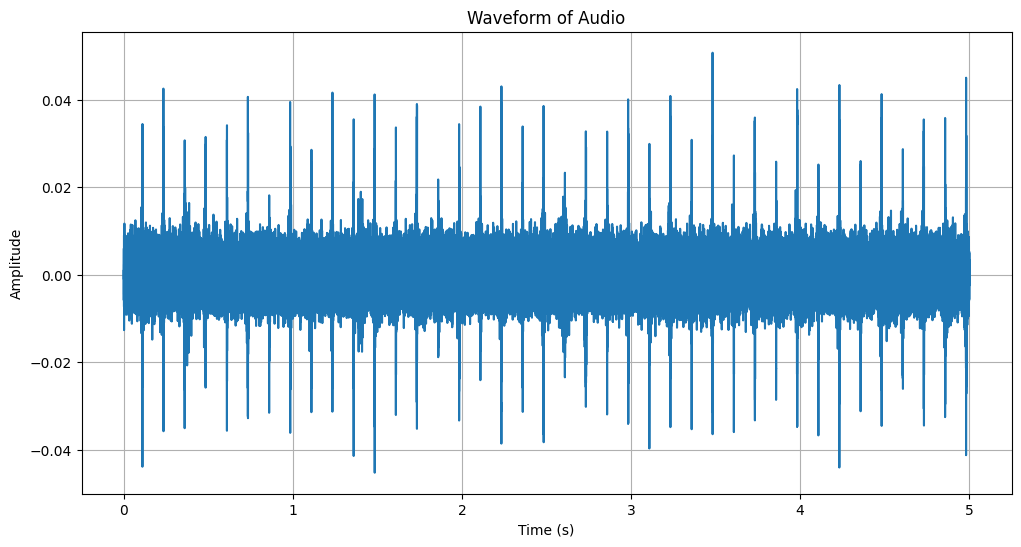

In [38]:
file_path = 'sample3.wav'

audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True, duration=PROCESSING_INTERVAL_SEC)

def plot_timeseries(audio, xlabel="Time (s)", ylabel="Amplitude", xmin=None, xmax=None, title="Waveform of Audio"):
    time_axis = np.linspace(0, len(audio) / SAMPLE_RATE, num=len(audio))
    plt.figure(figsize=(12, 6))
    plt.plot(time_axis,audio)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if xmin is not None or xmax is not None:
        plt.xlim(xmin, xmax)
        
    plt.grid()
    plt.show()

def plot_frequency(frequencies, magnitudes, xlabel="Frequency (hz)", ylabel="Amplitude", xmin=None, xmax=None, title="Frequency"):
    plt.figure(figsize=(12, 6))
    plt.plot(frequencies,magnitudes)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if xmin is not None or xmax is not None:
        plt.xlim(xmin, xmax)
        
    plt.grid()
    plt.show()

plot_timeseries(audio)

In [39]:
abs_audio = np.abs(audio)

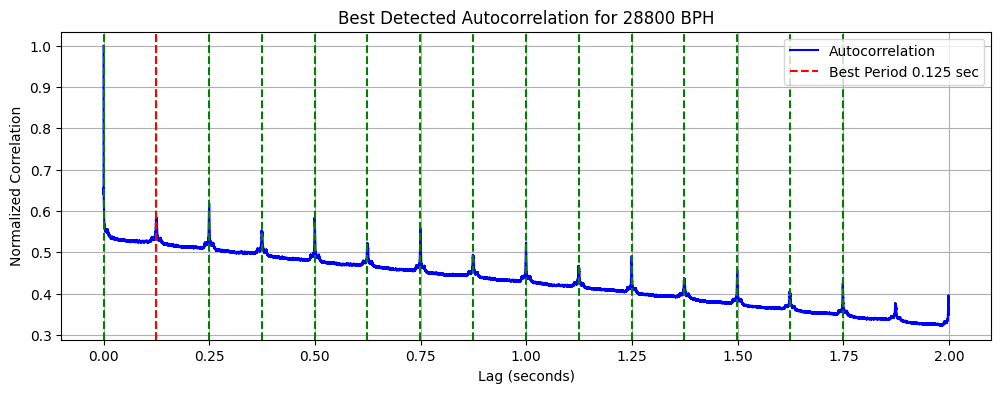


[RESULT] Detected period: 0.1250 seconds
[RESULT] Detected frequency: 8.00 Hz
[RESULT] Detected beat number: 28800 BPH


In [40]:
# detect period, bph, frequency
import scipy

def fast_autocorrelation(audio):
    n = len(audio)
    result = scipy.signal.fftconvolve(audio, audio[::-1], mode="full")
    result = result[n-1:]
    result /= np.max(result)
    return result

def detect_period(audio, beat_numbers, sr=SAMPLE_RATE, max_time_sec=2, min_peak_ratio=0.4, period_tolerance=0.02):
    autocorr = fast_autocorrelation(audio)
    max_lag_samples = int(max_time_sec * sr)
    global_max_peak = np.max(autocorr)

    best_beat_number = None
    best_period = None
    max_peak_count = 0
    best_peaks = []

    for beat_number in sorted(beat_numbers):
        expected_period = 3600 / beat_number
        expected_lag_samples = int(expected_period * sr)
        distance_samples = int(expected_lag_samples * (1 - period_tolerance))

        peaks, properties = signal.find_peaks(autocorr[:max_lag_samples], height=0.1, distance=distance_samples)
        strong_peaks = [p for p, h in zip(peaks, properties["peak_heights"]) if h > min_peak_ratio * global_max_peak]

        if len(strong_peaks) > max_peak_count or (len(strong_peaks) == max_peak_count and beat_number < best_beat_number):
            max_peak_count = len(strong_peaks)
            best_period = expected_period
            best_beat_number = beat_number
            best_peaks = strong_peaks

    if best_period:
        time_axis = np.arange(len(autocorr[:max_lag_samples])) / sr
        plt.figure(figsize=(12, 4))
        plt.plot(time_axis, autocorr[:max_lag_samples], label="Autocorrelation", color="blue")
        for peak in best_peaks:
            plt.axvline(peak / sr, color="green", linestyle="--")
        plt.axvline(best_period, color="red", linestyle="--", label=f"Best Period {best_period:.3f} sec")
        plt.xlabel("Lag (seconds)")
        plt.ylabel("Normalized Correlation")
        plt.title(f"Best Detected Autocorrelation for {best_beat_number} BPH")
        plt.legend()
        plt.grid()
        plt.show()

    return best_period, best_beat_number

detected_period, detected_bph = detect_period(abs_audio, AUTOMATIC_BEAT_NUMBERS)

if detected_period:
    detected_freq = 1 / detected_period
    print(f"\n[RESULT] Detected period: {detected_period:.4f} seconds")
    print(f"[RESULT] Detected frequency: {detected_freq:.2f} Hz")
    print(f"[RESULT] Detected beat number: {detected_bph:.0f} BPH")
else:
    print("\n[ERROR] No valid period detected.")


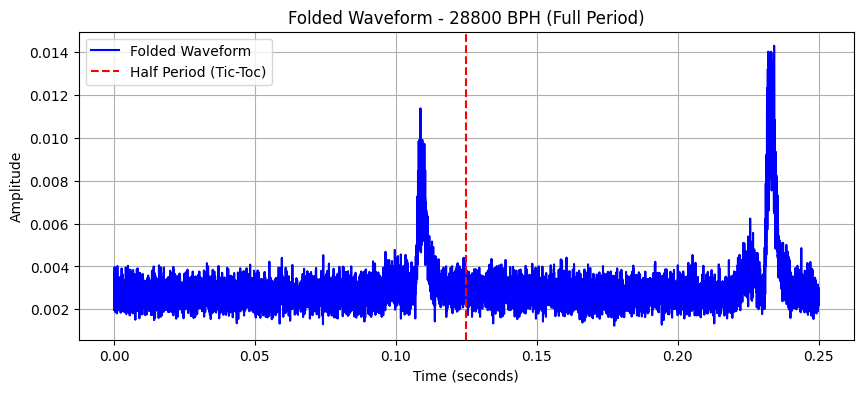

In [57]:
def compute_folded_waveform(audio, full_period, sr=SAMPLE_RATE, phase=0):
    period_samples = int(full_period * sr)
    folded_waveform = np.zeros(period_samples)
    count_per_sample = np.zeros(period_samples)

    for i in range(0, len(audio) - period_samples, period_samples):
        k = int((i + phase) % period_samples)
        cycle = audio[i:i + period_samples]

        if len(cycle) == period_samples:
            folded_waveform += cycle
            count_per_sample += 1

    folded_waveform /= np.maximum(count_per_sample, 1)

    phase_samples = np.linspace(0, full_period, period_samples, endpoint=False)

    return folded_waveform, phase_samples

folded_waveform, phase_samples = compute_folded_waveform(abs_audio, detected_period*2)

plt.figure(figsize=(10, 4))
plt.plot(phase_samples, folded_waveform, label="Folded Waveform", color="blue")
plt.axvline(phase_samples[len(phase_samples) // 2], color='red', linestyle='--', label="Half Period (Tic-Toc)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title(f"Folded Waveform - {detected_bph} BPH (Full Period)")
plt.legend()
plt.grid()
plt.show()


In [58]:
# Detect phase
def compute_phase(folded_waveform):
    x, y = 0, 0
    period = len(folded_waveform)

    for i in range(period):
        angle = i * 2 * np.pi / period
        x += folded_waveform[i] * np.cos(angle)
        y += folded_waveform[i] * np.sin(angle)

    phase = period * (np.pi + np.arctan2(y, x)) / (2 * np.pi)
    return phase

detected_phase = compute_phase(folded_waveform)
print(detected_phase)

4168.047351049827


In [42]:
# compute beat error and phase shift

In [43]:
# compute amplitude

In [44]:
# locate events (tic/toc timestamps)